This is a file where I use jyp notebook for all stuff

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from PIL import Image
# import sklearn
import pandas as pd
# import seaborn as sns
# from tqdm import tqdm

In [ ]:
#protein Atlas dataset
df = pd.read_json(r'raw data\proteinatlas.json')
df.head()

In [ ]:
df['Subcellular main location'].explode().unique()

# df["Subcellular additional location"].explode().unique()
# df['Protein class'].explode().unique()
# df['Biological process'].explode().unique() #227 different ones
# df['Molecular function'].explode().unique().size #131 different ones

array(['Cell Junctions', 'Cytosol', None, 'Golgi apparatus',
       'Nucleoplasm', 'Plasma membrane', 'Vesicles',
       'Endoplasmic reticulum', 'Nuclear speckles', 'Mitochondria',
       'Nucleoli fibrillar center', 'Nuclear membrane', 'Basal body',
       'Nuclear bodies', 'Nucleoli', 'Centrosome', 'Acrosome',
       'Principal piece', 'End piece', 'Equatorial segment',
       'Perinuclear theca', 'Lipid droplets', 'Mid piece',
       'Flagellar centriole', 'Microtubules', 'Centriolar satellite',
       'Nucleoli rim', 'Focal adhesion sites', 'Peroxisomes',
       'Cytoplasmic bodies', 'Intermediate filaments', 'Endosomes',
       'Lysosomes', 'Primary cilium', 'Cytokinetic bridge',
       'Mitotic spindle', 'Primary cilium transition zone', 'Annulus',
       'Actin filaments', 'Connecting piece', 'Primary cilium tip',
       'Mitotic chromosome', 'Midbody ring', 'Calyx', 'Midbody',
       'Microtubule ends', 'Rods & Rings', 'Aggresome', 'Cleavage furrow',
       'Kinetochore'], dty

In [5]:
#from the main data in Cell Atlass choose the next available columns
cols = [
    'Gene',
    'Uniprot',
    'Protein class',
    'Biological process',
    'Molecular function',
    'Subcellular main location'
]
list_cols = ['Uniprot', 'Protein class', 'Biological process', 'Molecular function']

df_sub = df[cols].copy()

for col in list_cols:
    if df_sub[col].apply(lambda x: isinstance(x, list)).any():
        df_sub[col] = df_sub[col].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)


In [6]:
df_Atlass_localizations = df_sub[df_sub['Subcellular main location'].notna()] #only choose the proteins where localization data is present
df_Atlass_localizations.to_csv('raw data/df_Atlass_localizations.csv', index=False)

In [13]:

# One-hot encode df_Atlass_localizations for 6 nuclear localizations + other
target_locs = {
    'Nucleoplasm': 'Nucleoplasm',
    'Nucleoli': 'Nucleoli',
    'Nuclear Bodies': 'Nuclear bodies',
    'Nuclear speckles': 'Nuclear speckles',
    'Nuclear membrane': 'Nuclear membrane',
    'Fibrillar center': 'Nucleoli fibrillar center',
}

def make_onehot(loc_list):
    if not isinstance(loc_list, list):
        loc_list = []
    row = {}
    any_target = False
    for col, atlas_name in target_locs.items():
        hit = int(atlas_name in loc_list)
        row[col] = hit
        if hit:
            any_target = True
    row['other'] = int(not any_target)
    return row

onehot_df = df_Atlass_localizations['Subcellular main location'].apply(make_onehot).apply(pd.Series)
df_Atlass_localizations = pd.concat([df_Atlass_localizations.reset_index(drop=True), onehot_df.reset_index(drop=True)], axis=1)
df_Atlass_localizations


,Gene,Uniprot,Protein class,Biological process,Molecular function,Subcellular main location,Nucleoplasm,Nucleoli,Nuclear Bodies,Nuclear speckles,Nuclear membrane,Fibrillar center,other
0,TSPAN6,O43657,Predicted membrane proteins,None,None,"[Cell Junctions, Cytosol]",0,0,0,0,0,0,1
1,SCYL3,Q8IZE3,"Enzymes, Predicted intracellular proteins",None,None,"[Golgi apparatus, Cytosol]",0,0,0,0,0,0,1
2,C1orf112,Q9NSG2,Predicted intracellular proteins,None,None,[Nucleoplasm],1,0,0,0,0,0,0
3,FGR,P09769,"Disease related genes, Enzymes, Plasma protein...","Immunity, Innate immunity","Kinase, Transferase, Tyrosine-protein kinase",[Plasma membrane],0,0,0,0,0,0,1
4,CFH,P08603,"Cancer-related genes, Disease related genes, H...","Complement alternate pathway, Host-virus inter...",None,[Vesicles],0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13597,HOMEZ,Q8IX15,"Predicted intracellular proteins, Transcriptio...","Transcription, Transcription regulation",DNA-binding,[Nucleoli],0,1,0,0,0,0,0
13598,ENSG00000290315,,Predicted intracellular proteins,None,None,"[Nucleoplasm, Cytosol, Rods & Rings]",1,0,0,0,0,0,0
13599,ENSG00000290317,C9JBD0,Predicted intracellular proteins,None,None,[Nucleoplasm],1,0,0,0,0,0,0
13600,SOD2,P04179,"Cancer-related genes, Disease related genes, E...",None,Oxidoreductase,[Mitochondria],0,0,0,0,0,0,1


In [ ]:
import ast
# Extract sequence string from df_swissprot and merge into df_Atlass_localizations
seq_df = df_swissprot[['primaryAccession', 'sequence']].copy()
seq_df['Sequence'] = seq_df['sequence'].apply(lambda x: ast.literal_eval(x)['value'] if isinstance(x, str) else x['value'])
seq_df = seq_df.rename(columns={'primaryAccession': 'Uniprot'})[['Uniprot', 'Sequence']]

# df_Atlass_localizations = pd.merge(df_Atlass_localizations, seq_df, on='Uniprot', how='left')
# df_Atlass_localizations.to_csv('processed_data/df_Atlass_nuclear_localizations.csv', index=False)

NameError: name 'df_swissprot' is not defined

In [ ]:
df_Atlass_localizations['Subcellular main location'].explode().unique()
# Nucleoplasm, Nucleoli, Nuclear Bodies, Nuclear speckles, Nuclear membrane, Fibrillar center

array(['Cell Junctions', 'Cytosol', 'Golgi apparatus', 'Nucleoplasm',
       'Plasma membrane', 'Vesicles', 'Endoplasmic reticulum',
       'Nuclear speckles', 'Mitochondria', 'Nucleoli fibrillar center',
       'Nuclear membrane', 'Basal body', 'Nuclear bodies', 'Nucleoli',
       'Centrosome', 'Acrosome', 'Principal piece', 'End piece',
       'Equatorial segment', 'Perinuclear theca', 'Lipid droplets',
       'Mid piece', 'Flagellar centriole', 'Microtubules',
       'Centriolar satellite', 'Nucleoli rim', 'Focal adhesion sites',
       'Peroxisomes', 'Cytoplasmic bodies', 'Intermediate filaments',
       'Endosomes', 'Lysosomes', 'Primary cilium', 'Cytokinetic bridge',
       'Mitotic spindle', 'Primary cilium transition zone', 'Annulus',
       'Actin filaments', 'Connecting piece', 'Primary cilium tip',
       'Mitotic chromosome', 'Midbody ring', 'Calyx', 'Midbody',
       'Microtubule ends', 'Rods & Rings', 'Aggresome', 'Cleavage furrow',
       'Kinetochore'], dtype=object)

In [7]:
df_deep_loc = pd.read_csv(r'raw data/Swissprot_Train_Validation_dataset DeepLoc 2.csv')
df_deep_loc = df_deep_loc.iloc[:, 1:]
df_deep_loc.rename(columns={"ACC": "Uniprot"}, inplace=True)
df_deep_loc_reduced = df_deep_loc[(df_deep_loc["Partition"] == 1) | (df_deep_loc["Partition"] == 2)]
df_deep_loc_reduced.to_csv(r"processed_data/df_deep_loc_reduced.csv", index=False)

In [8]:
df_deep_loc_reduced

,Uniprot,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
3,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
4,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...
8,P63086,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYDNLNK...
12,P21708,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAPGGGGGEPRGTAGVVPVVPGEVEVVKGQPFDVGPRYTQL...
16,Q9NXW9,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAETPEVLRECGCKGIRTCLICERQRGSDPPWELPPAKTYRF...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28290,Q9SJ20,Viridiplantae,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYVVKRDGRQETVHFDKITARLKKLSYGLSSDHCDPVLVAQKVCAG...
28292,P21524,Fungi,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYVYKRDGRKEPVQFDKITARISRLCYGLDPKHIDAVKVTQRIISG...
28293,P36639,Metazoa,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,MYWSNQITRRLGERVQGFMSGISPQQMGEPEGSWSGKNPGTMGASR...
28296,Q08032,Fungi,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYYGISQFSEAYNKILRNSSSHSSCQLVIFVSCLNIDALCATKMLS...


In [10]:
df_deep_loc_the_rest = df_deep_loc[(df_deep_loc["Partition"] != 1) | (df_deep_loc["Partition"] != 2)]
df_deep_loc_the_rest.to_csv(r"processed_data/df_deep_loc_the_rest.csv", index=False)
df_deep_loc_the_rest

,Uniprot,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
0,Q28165,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
1,Q86U42,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
2,Q0GA42,Metazoa,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAALGVRLRDCCSRGAVLLLFFSLSPRPPAAAAWLLGLR...
3,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
4,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28298,Q09712,Fungi,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,MYYIGHPSYYRKHIEHVCFQHSGILKKRNYQKNQKKYIMKLNESAM...
28299,Q9V3C5,Metazoa,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,MYYPVGWPKRVGLALPGESASIRHICCDAVKILVAAVGDDFLGIWY...
28300,Q9SQQ9,Viridiplantae,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYYQNQHQGKNILSSSRMHITSERHPFLRGNSPGDSGLILSTDAKP...
28301,Q9SQQ9-3,Viridiplantae,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYYQNQHQGKNILSSSRMHITSERHPFLRGNSPGDSGLILSTDAKP...


In [35]:
df_merged_deeploc_and_protein_atlas = pd.merge(df_deep_loc, df_Atlass_localizations, on='Uniprot', how='inner')
df_merged_deeploc_and_protein_atlas.head()

,Uniprot,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence,Gene,Protein class,Biological process,Molecular function,Subcellular main location
0,Q86U42,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...,PABPN1,"Disease related genes, Essential proteins, Hum...",mRNA processing,RNA-binding,"[Nucleoplasm, Nuclear speckles]"
1,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...,COPS6,"Enzymes, Essential proteins, Predicted intrace...",Host-virus interaction,None,[Nucleoplasm]
2,Q96S94,Metazoa,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAGAAGSAAPAAAAGAPGSGGAPSGSQGVLIGDRLYSGVL...,CCNL2,Predicted intracellular proteins,"Transcription, Transcription regulation",Cyclin,[Nucleoplasm]
3,Q96P70,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAGAASGLPGPVAQGLKEALVDTLTGILSPVQEVRAAAEEQ...,IPO9,"Essential proteins, Predicted intracellular pr...","Protein transport, Transport",Chaperone,[Cytosol]
4,Q9UID3,Metazoa,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,MAAAAAAGPSPGSGPGDSPEGPEGEAPERRRKAHGMLKLYYGLSEG...,VPS51,"Disease related genes, Essential proteins, Hum...","Lipid transport, Protein transport, Transport",None,"[Golgi apparatus, Vesicles]"


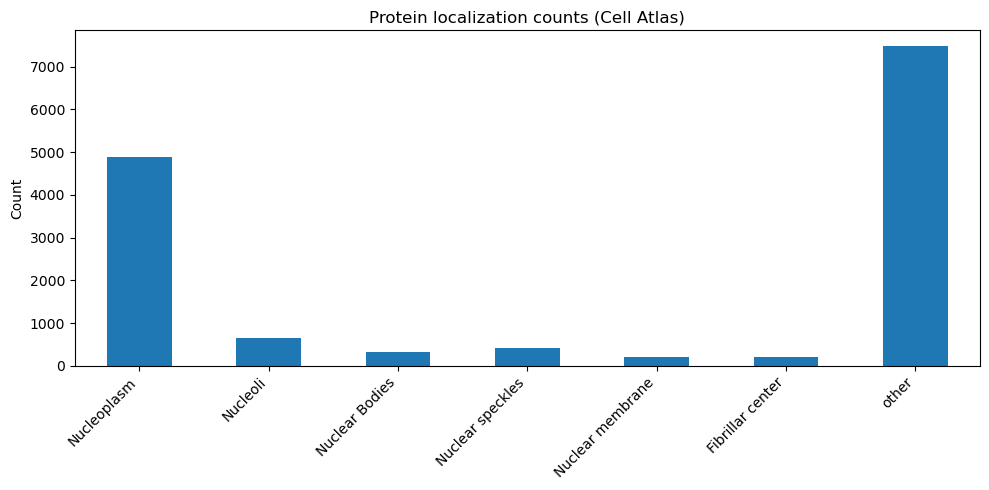

Nucleoplasm         4897
Nucleoli             638
Nuclear Bodies       326
Nuclear speckles     412
Nuclear membrane     193
Fibrillar center     193
other               7479
dtype: int64


In [20]:
atlas_locations = ['Nucleoplasm', 'Nucleoli', 'Nuclear Bodies', 'Nuclear speckles',
                   'Nuclear membrane', 'Fibrillar center', 'other']

sums_atlas = df_Atlass_localizations[atlas_locations].sum()

plt.figure(figsize=(10, 5))
sums_atlas.plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Protein localization counts (Cell Atlas)')
plt.tight_layout()
plt.show()

print(sums_atlas)

In [12]:
#freaking humangous, don't run this line unless you're ready for several GB RAM
# df_uniprot_swissprot = pd.read_json(r'raw data\uniprotkb_reviewed_true_2026_05_10.json') 
# df_uniprot_swissprot.head()


#This code takes BIG swossprot 500k proteins dataset and extracts only 13k which were done in Cell Atlass

# import ijson
# # Build a set of the IDs you want — O(1) lookup
# uniprot_ids = set(df_Atlass_localizations['Uniprot'].dropna())

# records = []
# with open(r'raw data\uniprotkb_reviewed_true_2026_05_10.json', 'rb') as f:
#     # UniProt JSON downloads wrap results: {"results": [...]}
#     for protein in ijson.items(f, 'results.item'):
#         if protein.get('primaryAccession') in uniprot_ids:
#             records.append(protein)

# df_swissprot = pd.DataFrame(records)
# print(f"Matched {len(df_swissprot)} / {len(uniprot_ids)} proteins")
# df_swissprot.to_csv('raw data/uniprot_swiss truncated.csv', index=False)



In [15]:
df_swissprot = pd.read_csv('raw data/uniprot_swiss truncated.csv')
df_swissprot.head()

,entryType,primaryAccession,secondaryAccessions,uniProtkbId,entryAudit,annotationScore,organism,proteinExistence,proteinDescription,genes,comments,features,keywords,references,uniProtKBCrossReferences,sequence,extraAttributes,geneLocations
0,UniProtKB reviewed (Swiss-Prot),A0A096LP01,['A0A096LPB2'],SIM26_HUMAN,"{'firstPublicDate': '2017-07-05', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'evidences':...,[{'geneName': {'evidences': [{'evidenceCode': ...,[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0025', 'category': 'Coding sequenc...","[{'referenceNumber': 1, 'citation': {'id': '34...","[{'database': 'EMBL', 'id': 'MW979249', 'prope...",{'value': 'MYRNEFTAWYRRMSVVYGIGTWSVLGSLLYYSRTM...,"{'countByCommentType': {'FUNCTION': 1, 'SUBUNI...",NaN
1,UniProtKB reviewed (Swiss-Prot),A0AV02,"['C9JJJ2', 'Q68D04', 'Q6I9Z2', 'Q6P4C0', 'Q7Z3...",S12A8_HUMAN,"{'firstPublicDate': '2007-10-02', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'value': 'So...,"[{'geneName': {'value': 'SLC12A8'}, 'synonyms'...",[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0025', 'category': 'Coding sequenc...","[{'referenceNumber': 1, 'citation': {'id': '11...","[{'database': 'EMBL', 'id': 'AF389851', 'prope...",{'value': 'MTQMSQVQELFHEAAQQDALAQPQPWWKTQLFMWE...,"{'countByCommentType': {'FUNCTION': 1, 'INTERA...",NaN
2,UniProtKB reviewed (Swiss-Prot),A0AV96,"['A0PJK2', 'B5MED4', 'Q8NI52', 'Q8NI53', 'Q9NX...",RBM47_HUMAN,"{'firstPublicDate': '2007-10-23', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'evidences':...,[{'geneName': {'evidences': [{'evidenceCode': ...,[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': 'CI...","[{'database': 'EMBL', 'id': 'AF261889', 'prope...",{'value': 'MTAEDSTAAMSSDSAAGSSAKVPEGVAGAPNEAAL...,"{'countByCommentType': {'FUNCTION': 1, 'SUBUNI...",NaN
3,UniProtKB reviewed (Swiss-Prot),A0AVF1,"['A4D1S3', 'B7Z5M0', 'C9J2N7', 'F8W724', 'Q9H9...",IFT56_HUMAN,"{'firstPublicDate': '2007-05-29', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'evidences':...,[{'geneName': {'evidences': [{'evidenceCode': ...,[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0025', 'category': 'Coding sequenc...","[{'referenceNumber': 1, 'citation': {'id': '14...","[{'database': 'EMBL', 'id': 'AK022633', 'prope...",{'value': 'MMLSRAKPAVGRGVQHTDKRKKKGRKIPKLEELLS...,"{'countByCommentType': {'FUNCTION': 1, 'SUBUNI...",NaN
4,UniProtKB reviewed (Swiss-Prot),A0AVK6,"['A8K9H3', 'Q2VPJ3', 'Q3C1U6', 'Q5BKY4', 'Q8N3...",E2F8_HUMAN,"{'firstPublicDate': '2007-08-21', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'value': 'Tr...,[{'geneName': {'value': 'E2F8'}}],[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': '14...","[{'database': 'EMBL', 'id': 'AK026964', 'prope...",{'value': 'MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEI...,"{'countByCommentType': {'FUNCTION': 1, 'SUBUNI...",NaN


In [ ]:
# ast.literal_eval(df_swissprot['sequence'][0])

{'value': 'MYRNEFTAWYRRMSVVYGIGTWSVLGSLLYYSRTMAKSSVDQKDGSASEVPSELSERPKGFYVETVVTYKEDFVPNTEKILNYWKSWTGGPGTEP',
 'length': 95,
 'molWeight': 10908,
 'crc64': 'DEC57BBD71737916',
 'md5': 'E2A0897CA76EB628906E015FE2770E06'}

In [ ]:
# import ast
# ast.literal_eval(df_swissprot['comments'][0])

[{'texts': [{'evidences': [{'evidenceCode': 'ECO:0000269',
      'source': 'PubMed',
      'id': '34445188'}],
    'value': 'May play a role in cell viability'}],
  'commentType': 'FUNCTION'},
 {'texts': [{'evidences': [{'evidenceCode': 'ECO:0000269',
      'source': 'PubMed',
      'id': '37009826'}],
    'value': 'Interacts with AGK and SLC25A11'}],
  'commentType': 'SUBUNIT'},
 {'commentType': 'INTERACTION',
  'interactions': [{'interactantOne': {'uniProtKBAccession': 'A0A096LP01',
     'intActId': 'EBI-50428917'},
    'interactantTwo': {'uniProtKBAccession': 'Q53H12',
     'geneName': 'AGK',
     'intActId': 'EBI-2269837'},
    'numberOfExperiments': 18,
    'organismDiffer': False},
   {'interactantOne': {'uniProtKBAccession': 'A0A096LP01',
     'intActId': 'EBI-50428917'},
    'interactantTwo': {'uniProtKBAccession': 'Q02978',
     'geneName': 'SLC25A11',
     'intActId': 'EBI-359174'},
    'numberOfExperiments': 12,
    'organismDiffer': False}]},
 {'commentType': 'SUBCELLULAR L

In [ ]:
# ast.literal_eval(df_swissprot['proteinDescription'][0])

{'recommendedName': {'fullName': {'evidences': [{'evidenceCode': 'ECO:0000312',
     'source': 'HGNC',
     'id': 'HGNC:43430'}],
   'value': 'Small integral membrane protein 26'}}}

In [ ]:
# ast.literal_eval(df_swissprot['extraAttributes'][0])

{'countByCommentType': {'FUNCTION': 1,
  'SUBUNIT': 1,
  'INTERACTION': 2,
  'SUBCELLULAR LOCATION': 1,
  'ALTERNATIVE PRODUCTS': 2,
  'TISSUE SPECIFICITY': 1,
  'MISCELLANEOUS': 1,
  'SIMILARITY': 1},
 'countByFeatureType': {'Chain': 1,
  'Transmembrane': 1,
  'Alternative sequence': 1},
 'uniParcId': 'UPI000021D406'}

In [2]:
pd.read_csv("raw data/hpa_testset.csv")

,sid,Cell membrane,Cytoplasm,Endoplasmic reticulum,Golgi apparatus,Lysosome/Vacuole,Mitochondrion,Nucleus,Peroxisome,Lengths,fasta
0,ENSP00000355743,0,0,0,0,0,0,1,0,496,MAAAAGPGAALSPRPCDSDPATPGAQSPKDDNEDNSNDGTQPSKRR...
1,ENSP00000429628,0,0,0,0,0,0,1,0,173,MAAAALRDPAQVPVAADLLTDHEEGYVTFEDVAVYFSQEEWRLLDD...
2,ENSP00000266544,0,0,0,0,0,1,0,0,377,MAAAAQSRVVRVLSMSRSAITAIATSVCHGPPCRQLHHALMPHGKG...
3,ENSP00000470652,0,0,0,1,0,0,0,0,410,MAAAAVGAGHGAGGPGAASSSGGAREGARVAALCLLWYALSAGGNV...
4,ENSP00000460751,0,0,0,0,0,0,1,0,163,MAAAAVTRGTPGENSHHLKIFLPKKLLECLPRCPLLPPERLRWNTN...
...,...,...,...,...,...,...,...,...,...,...,...
1712,ENSP00000379284,0,0,0,0,0,1,0,0,372,MYSCFSHREGEDWQRVRSAFQKKLMKPGEVMKLDNKINEVLADFMG...
1713,ENSP00000430164,0,1,0,0,0,0,0,0,73,MYSGAGPGKSWNTWSSTLKHRSLGIGSPCLTAGRIYTQPCPFRLGG...
1714,ENSP00000414655,0,1,0,0,0,0,0,0,174,MYSPIIYQALCEHVQTQMSLMNDLTSKNIPNGIPAVPCHAPSHSES...
1715,ENSP00000392070,0,0,0,0,0,0,1,0,327,MYYAREPGKINHMRYDTLAQMLTLGNIRAGNKMIVMETCAGLVLGA...


In [35]:
df_Atlass_nuclear_localizations = pd.read_csv("processed_data\df_Atlass_nuclear_localizations.csv")
# df_Atlass_nuclear_localizations = df_Atlass_nuclear_localizations[df_Atlass_nuclear_localizations["Sequence_x"].notna()].iloc[:,1:-1]
# df_Atlass_nuclear_localizations = df_Atlass_nuclear_localizations.rename(columns={'Sequence_x': 'sequence'})
# # [['Uniprot', 'Sequence']]
# df_Atlass_nuclear_localizations.to_csv("processed_data\df_Atlass_nuclear_localizations.csv", index = False)
df_Atlass_nuclear_localizations

,Gene,Uniprot,Protein class,Biological process,Molecular function,Subcellular main location,Nucleoplasm,Nucleoli,Nuclear Bodies,Nuclear speckles,Nuclear membrane,Fibrillar center,other,sequence
0,TSPAN6,O43657,Predicted membrane proteins,NaN,NaN,"['Cell Junctions', 'Cytosol']",0,0,0,0,0,0,1,MASPSRRLQTKPVITCFKSVLLIYTFIFWITGVILLAVGIWGKVSL...
1,SCYL3,Q8IZE3,"Enzymes, Predicted intracellular proteins",NaN,NaN,"['Golgi apparatus', 'Cytosol']",0,0,0,0,0,0,1,MGSENSALKSYTLREPPFTLPSGLAVYPAVLQDGKFASVFVYKREN...
2,C1orf112,Q9NSG2,Predicted intracellular proteins,NaN,NaN,['Nucleoplasm'],1,0,0,0,0,0,0,MFLPHMNHLTLEQTFFSQVLPKTVKLFDDMMYELTSQARGLSSQNL...
3,FGR,P09769,"Disease related genes, Enzymes, Plasma protein...","Immunity, Innate immunity","Kinase, Transferase, Tyrosine-protein kinase",['Plasma membrane'],0,0,0,0,0,0,1,MGCVFCKKLEPVATAKEDAGLEGDFRSYGAADHYGPDPTKARPASS...
4,CFH,P08603,"Cancer-related genes, Disease related genes, H...","Complement alternate pathway, Host-virus inter...",NaN,['Vesicles'],0,0,0,0,0,0,1,MRLLAKIICLMLWAICVAEDCNELPPRRNTEILTGSWSDQTYPEGT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13312,H2AC19,Q6FI13,Predicted intracellular proteins,NaN,DNA-binding,['Nucleoplasm'],1,0,0,0,0,0,0,MSGRGKQGGKARAKAKSRSSRAGLQFPVGRVHRLLRKGNYAERVGA...
13313,ENSG00000290147,P43080,"Disease related genes, Predicted intracellular...","Sensory transduction, Vision",NaN,['Plasma membrane'],0,0,0,0,0,0,1,MGNVMEGKSVEELSSTECHQWYKKFMTECPSGQLTLYEFRQFFGLK...
13314,HOMEZ,Q8IX15,"Predicted intracellular proteins, Transcriptio...","Transcription, Transcription regulation",DNA-binding,['Nucleoli'],0,1,0,0,0,0,0,MVRGWEPPPGLDCAISEGHKSEGTMPPNKEASGLSSSPAGLICLPP...
13315,ENSG00000290317,C9JBD0,Predicted intracellular proteins,NaN,NaN,['Nucleoplasm'],1,0,0,0,0,0,0,MMTAVSLTTRPQESVAFEDVAVYFTTKEWAIMVPAERALYRDVMLE...


13317